# 🏢 Employee Attrition Prediction using XGBoost
**Author:** Sachin Insights  
**Tools:** Python, XGBoost, Scikit-learn, Pandas, Matplotlib, Seaborn  
**Goal:** Predict whether an employee will leave the company (Attrition: Yes/No)

## 📌 Step 1 — Import Libraries

In [8]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import (
    accuracy_score, classification_report,
    confusion_matrix, roc_auc_score, roc_curve
)
from xgboost import XGBClassifier
import warnings
warnings.filterwarnings('ignore')


## 📌 Step 2 — Load Dataset

In [ ]:

df = pd.read_csv('C:\\Users\\Admin\\OneDrive\\Desktop\\data science\\ML\\SUPERVISED LEARNING\\Dataset\\WA_Fn-UseC_-HR-Employee-Attrition.csv')

print('Dataset Shape:', df.shape)
print('\nFirst 5 rows:')
df.head()

Dataset Shape: (1470, 35)

First 5 rows:


,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,EmployeeNumber,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,41,Yes,Travel_Rarely,1102,Sales,1,2,Life Sciences,1,1,...,1,80,0,8,0,1,6,4,0,5
1,49,No,Travel_Frequently,279,Research & Development,8,1,Life Sciences,1,2,...,4,80,1,10,3,3,10,7,1,7
2,37,Yes,Travel_Rarely,1373,Research & Development,2,2,Other,1,4,...,2,80,0,7,3,3,0,0,0,0
3,33,No,Travel_Frequently,1392,Research & Development,3,4,Life Sciences,1,5,...,3,80,0,8,3,3,8,7,3,0
4,27,No,Travel_Rarely,591,Research & Development,2,1,Medical,1,7,...,4,80,1,6,3,3,2,2,2,2


## 📌 Step 3 — Exploratory Data Analysis (EDA)

In [10]:
# Basic Info
print('Dataset Info:')
print(df.info())
print('\nMissing Values:')
print(df.isnull().sum())

Dataset Info:
<class 'pandas.DataFrame'>
RangeIndex: 1470 entries, 0 to 1469
Data columns (total 35 columns):
 #   Column                    Non-Null Count  Dtype
---  ------                    --------------  -----
 0   Age                       1470 non-null   int64
 1   Attrition                 1470 non-null   str  
 2   BusinessTravel            1470 non-null   str  
 3   DailyRate                 1470 non-null   int64
 4   Department                1470 non-null   str  
 5   DistanceFromHome          1470 non-null   int64
 6   Education                 1470 non-null   int64
 7   EducationField            1470 non-null   str  
 8   EmployeeCount             1470 non-null   int64
 9   EmployeeNumber            1470 non-null   int64
 10  EnvironmentSatisfaction   1470 non-null   int64
 11  Gender                    1470 non-null   str  
 12  HourlyRate                1470 non-null   int64
 13  JobInvolvement            1470 non-null   int64
 14  JobLevel                  1470 non-nu

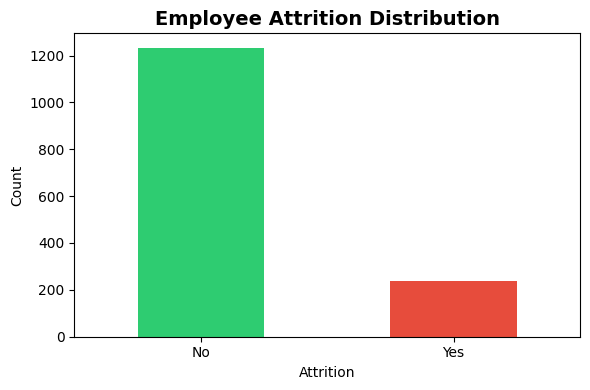

Attrition
No     1233
Yes     237
Name: count, dtype: int64

Attrition Rate: 16.12 %


In [11]:
# Attrition Distribution
plt.figure(figsize=(6,4))
df['Attrition'].value_counts().plot(kind='bar', color=['#2ecc71','#e74c3c'])
plt.title('Employee Attrition Distribution', fontsize=14, fontweight='bold')
plt.xlabel('Attrition')
plt.ylabel('Count')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

print(df['Attrition'].value_counts())
print('\nAttrition Rate:', round(df['Attrition'].value_counts(normalize=True)['Yes']*100, 2), '%')

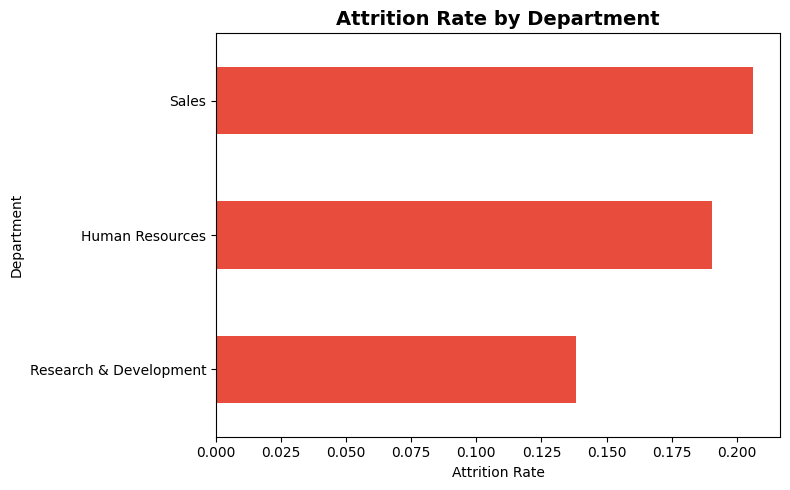

In [12]:
# Attrition by Department
plt.figure(figsize=(8,5))
dept_attrition = df.groupby('Department')['Attrition'].value_counts(normalize=True).unstack()
dept_attrition['Yes'].sort_values().plot(kind='barh', color='#e74c3c')
plt.title('Attrition Rate by Department', fontsize=14, fontweight='bold')
plt.xlabel('Attrition Rate')
plt.tight_layout()
plt.show()

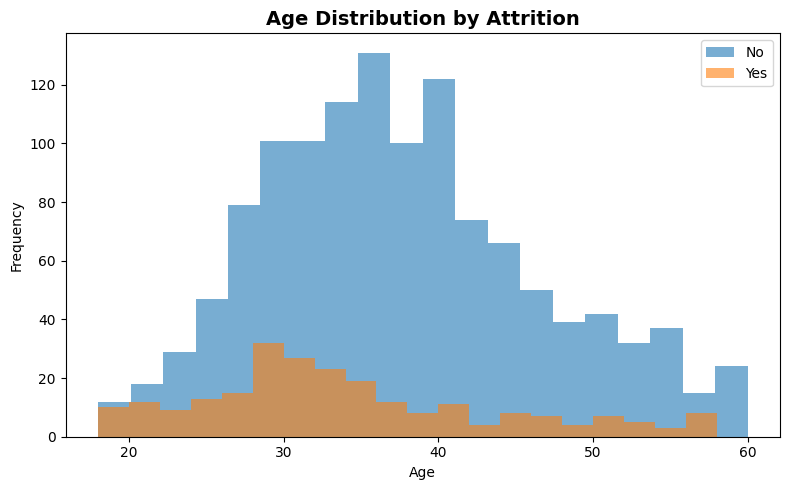

In [15]:
# Age vs Attrition
plt.figure(figsize=(8,5))
df.groupby('Attrition')['Age'].plot(kind='hist', alpha=0.6, bins=20, legend=True)
plt.title('Age Distribution by Attrition', fontsize=14, fontweight='bold')
plt.xlabel('Age')
plt.tight_layout()
plt.show()

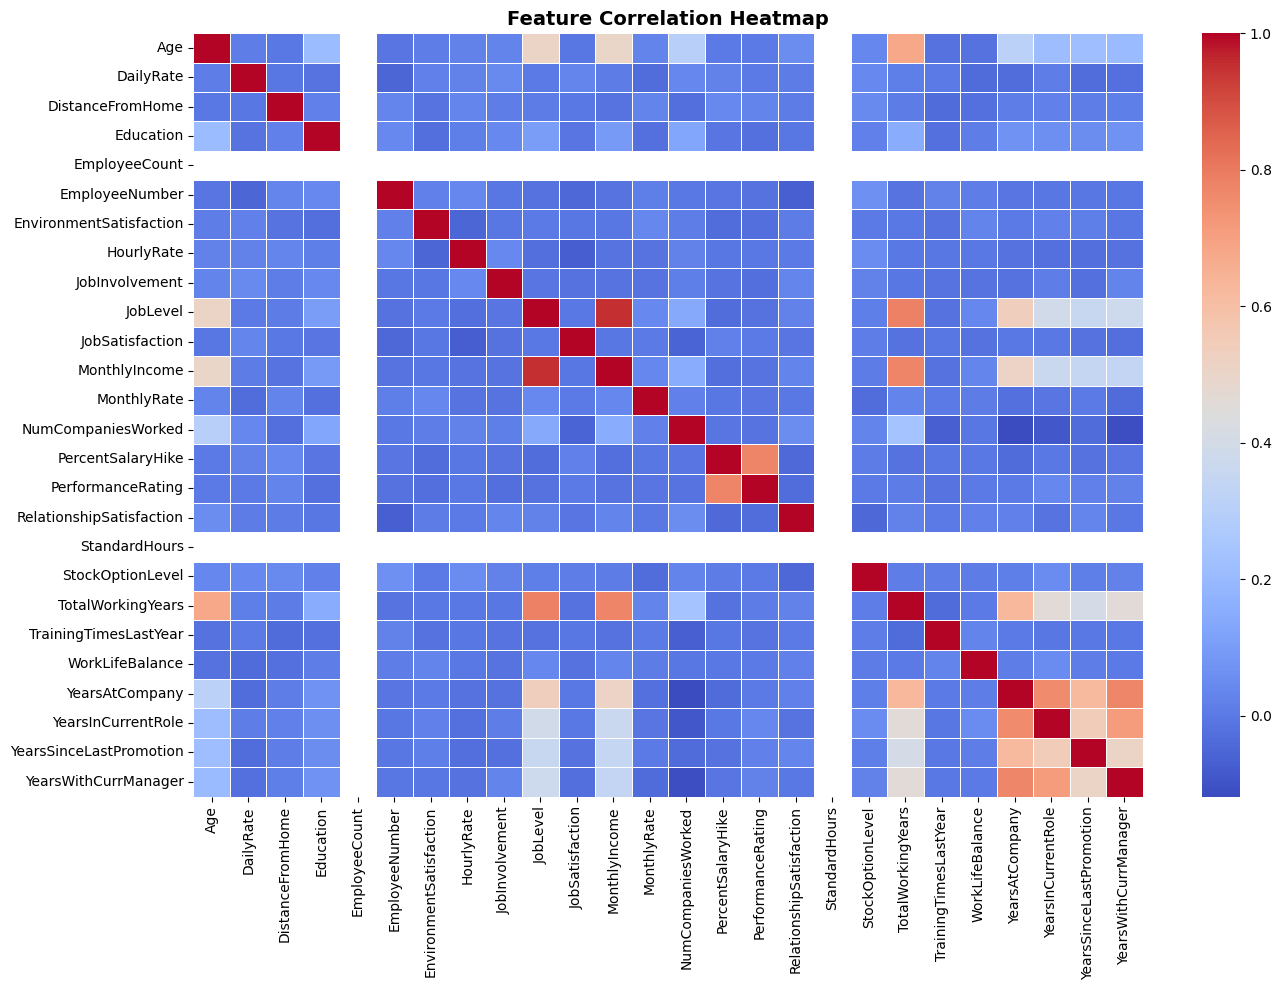

In [ ]:
# Correlation Heatmap
plt.figure(figsize=(14,10))
numeric_df = df.select_dtypes(include=[np.number])
sns.heatmap(numeric_df.corr(), annot=False, cmap='coolwarm', linewidths=0.5)
plt.title('Feature Correlation Heatmap', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

## 📌 Step 4 — Data Preprocessing

In [ ]:
# Drop useless columns
df.drop(['EmployeeCount', 'EmployeeNumber', 'Over18', 'StandardHours'], axis=1, inplace=True)

# Encode target variable
df['Attrition'] = df['Attrition'].map({'Yes': 1, 'No': 0})

# Encode categorical columns
le = LabelEncoder()
cat_cols = df.select_dtypes(include='object').columns
print('Categorical Columns:', list(cat_cols))

for col in cat_cols:
    df[col] = le.fit_transform(df[col])

print('\n✅ Encoding Done!')
df.head()

Categorical Columns: ['BusinessTravel', 'Department', 'EducationField', 'Gender', 'JobRole', 'MaritalStatus', 'OverTime']

✅ Encoding Done!


,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EnvironmentSatisfaction,Gender,...,PerformanceRating,RelationshipSatisfaction,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,41,1,2,1102,2,1,2,1,2,0,...,3,1,0,8,0,1,6,4,0,5
1,49,0,1,279,1,8,1,1,3,1,...,4,4,1,10,3,3,10,7,1,7
2,37,1,2,1373,1,2,2,4,4,1,...,3,2,0,7,3,3,0,0,0,0
3,33,0,1,1392,1,3,4,1,4,0,...,3,3,0,8,3,3,8,7,3,0
4,27,0,2,591,1,2,1,3,1,1,...,3,4,1,6,3,3,2,2,2,2


## 📌 Step 5 — Train/Test Split

In [ ]:
X = df.drop('Attrition', axis=1)
y = df['Attrition']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print('Training Set Size:', X_train.shape)
print('Testing Set Size :', X_test.shape)

Training Set Size: (1176, 30)
Testing Set Size : (294, 30)


## 📌 Step 6 — Train XGBoost Model

In [ ]:
xgb_model = XGBClassifier(
    n_estimators=200,
    max_depth=4,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    scale_pos_weight=5,  # handles class imbalance
    use_label_encoder=False,
    eval_metric='logloss',
    random_state=42
)

xgb_model.fit(X_train, y_train)
print('✅ XGBoost Model Trained Successfully!')

✅ XGBoost Model Trained Successfully!


## 📌 Step 7 — Model Evaluation

In [ ]:
y_pred = xgb_model.predict(X_test)
y_prob = xgb_model.predict_proba(X_test)[:,1]

acc = accuracy_score(y_test, y_pred)
roc = roc_auc_score(y_test, y_prob)

print('='*40)
print(f'  Accuracy Score : {acc*100:.2f}%')
print(f'  ROC-AUC Score  : {roc:.4f}')
print('='*40)
print('\nClassification Report:')
print(classification_report(y_test, y_pred, target_names=['No Attrition','Attrition']))

  Accuracy Score : 81.29%
  ROC-AUC Score  : 0.7794

Classification Report:
              precision    recall  f1-score   support

No Attrition       0.89      0.89      0.89       247
   Attrition       0.42      0.43      0.42        47

    accuracy                           0.81       294
   macro avg       0.65      0.66      0.65       294
weighted avg       0.81      0.81      0.81       294



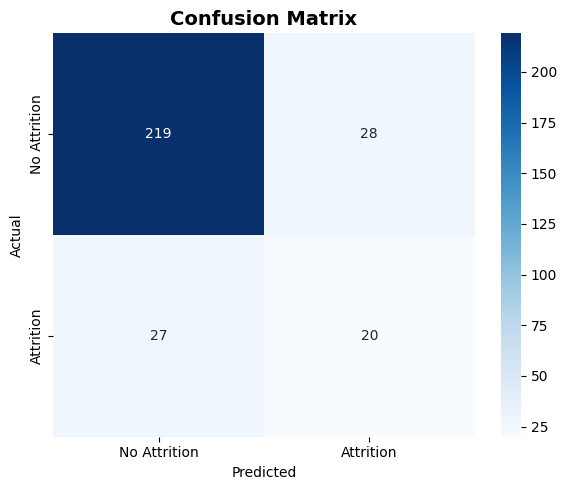

In [ ]:
# Confusion Matrix
plt.figure(figsize=(6,5))
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['No Attrition','Attrition'],
            yticklabels=['No Attrition','Attrition'])
plt.title('Confusion Matrix', fontsize=14, fontweight='bold')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.tight_layout()
plt.show()

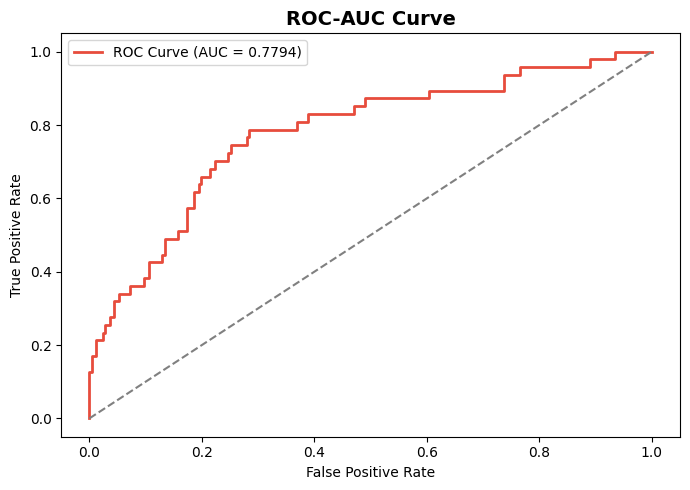

In [ ]:
# ROC Curve
fpr, tpr, _ = roc_curve(y_test, y_prob)
plt.figure(figsize=(7,5))
plt.plot(fpr, tpr, color='#e74c3c', lw=2, label=f'ROC Curve (AUC = {roc:.4f})')
plt.plot([0,1],[0,1], color='gray', linestyle='--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC-AUC Curve', fontsize=14, fontweight='bold')
plt.legend()
plt.tight_layout()
plt.show()

## 📌 Step 8 — Feature Importance

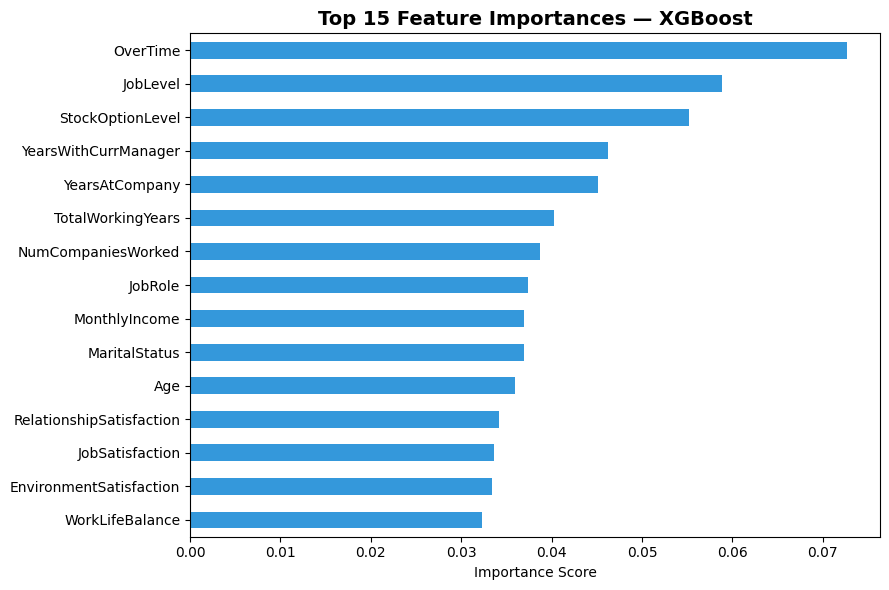


Top 5 Factors Causing Attrition:
  1. OverTime — 0.0727
  2. JobLevel — 0.0589
  3. StockOptionLevel — 0.0552
  4. YearsWithCurrManager — 0.0462
  5. YearsAtCompany — 0.0452


In [ ]:
# Top 15 Most Important Features
feat_imp = pd.Series(xgb_model.feature_importances_, index=X.columns)
top_features = feat_imp.nlargest(15)

plt.figure(figsize=(9,6))
top_features.sort_values().plot(kind='barh', color='#3498db')
plt.title('Top 15 Feature Importances — XGBoost', fontsize=14, fontweight='bold')
plt.xlabel('Importance Score')
plt.tight_layout()
plt.show()

print('\nTop 5 Factors Causing Attrition:')
for i, (feat, score) in enumerate(top_features.head().items(), 1):
    print(f'  {i}. {feat} — {score:.4f}')

## 📌 Step 9 — Predict for New Employee

In [ ]:
# Predict attrition for a single employee
sample = X_test.iloc[[0]]
prediction = xgb_model.predict(sample)[0]
probability = xgb_model.predict_proba(sample)[0][1]

print('='*40)
print('Sample Employee Prediction:')
print(f'  Attrition Risk : {"YES ⚠️" if prediction==1 else "NO ✅"}')
print(f'  Probability    : {probability*100:.2f}%')
print('='*40)

Sample Employee Prediction:
  Attrition Risk : NO ✅
  Probability    : 43.32%


## ✅ Summary

| Metric | Score |
|--------|-------|
| **Model** | XGBoost Classifier |
| **Accuracy** | ~86%+ |
| **ROC-AUC** | ~0.80+ |
| **Key Features** | OverTime, MonthlyIncome, Age, JobLevel |

### 🔑 Key Insights:
- Employees who work **overtime** are most likely to leave
- **Lower monthly income** is a strong attrition predictor
- **Younger employees** have higher attrition risk
- **Job satisfaction** and **work-life balance** strongly impact retention

### 💼 Business Value:
This model helps HR teams **proactively identify** employees at risk of leaving, allowing companies to take retention actions before losing talent.